# DTLZ2 Results

In [1]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 10
NPOP = 800
NGEN = 300
NOBJ = 4 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz2_segura = partial(benchmarks.dtlz2, obj=NOBJ)
toolbox = build_toolbox(func_dtlz2_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 50
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[0.0, 0.0, 3.9189282522379474e-17, 0.5000363023675363, 0.5000797967774028, 0.4999224152471488, 0.5000183470867938, 0.5001936817340907, 0.4998655066499105, 0.4994843188042556, 0.500232692028763, 0.4998997738569839, 0.49997824609408087]
[1.0, 0.0, 2.595344270886718e-13, 0.5000337412066194, 0.5641326007192752, 0.49993725364613145, 0.5000191222483659, 0.5001976309830557, 0.5374116560763589, 0.4998103584225859, 0.5003708351764847, 0.44506287563227526, 0.49999057824221066]
[1.543860155038303e-15, 0.0, 0.9999934338862533, 0.5021159105020572, 0.5895918369534916, 0.8775963243632876, 0.5582679700062976, 0.5060358550584318, 0.4990927142883186, 0.49994892869814084, 0.49974232224890935, 0.6976296693496044, 0.49994479807885917]
[1.0, 1.0, 1.0, 0.5000353380479579, 0.5000354776547139, 0.4999312586857092, 0.5000244069627866, 0.500094210337847, 0.5000003318801085, 0.4999691226388722, 0.4999638758032994, 0.4999602225286544, 0.49996936754798177]
[0.9999999999999998, 1.0, 0.0, 0.5000427015718001, 0.5000304

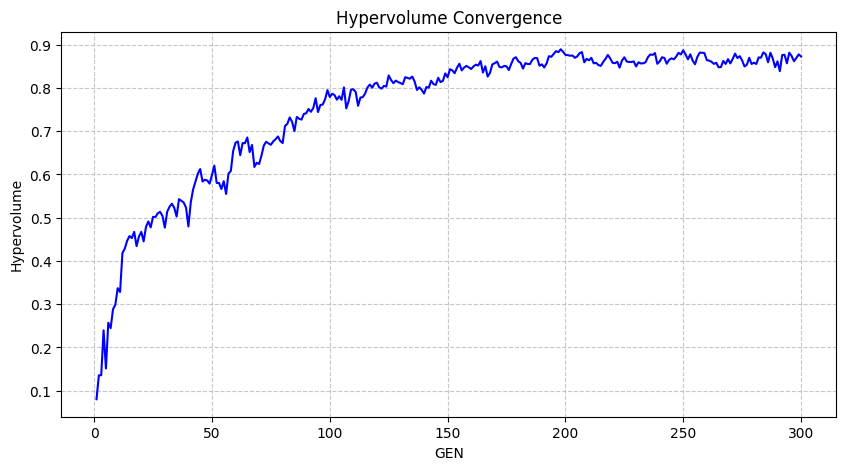

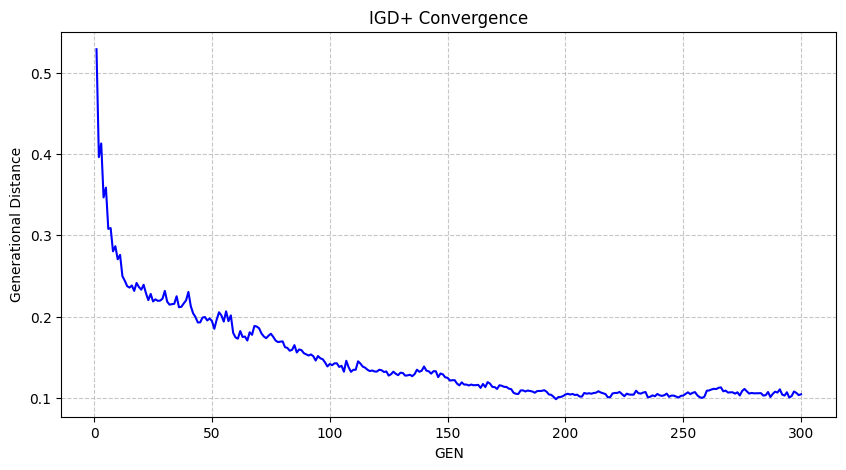

In [3]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()